In [14]:
import msprime
from matplotlib import pyplot as plt
import numpy as np
import concurrent.futures as cf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [15]:
pop_size = 10000000
n = 5
loci=1000

<BarContainer object of 4 artists>

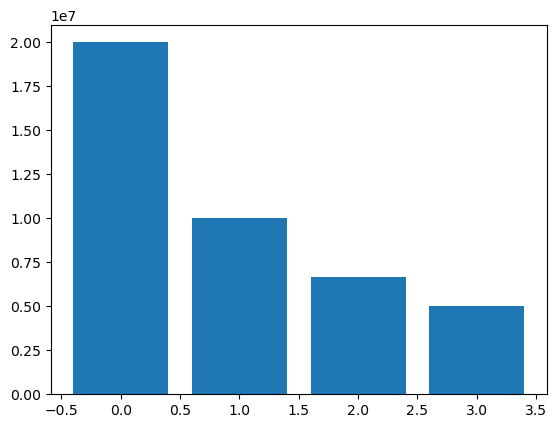

In [16]:
theoritical_sfs = [2*pop_size/(i+1) for i in range(n-1)]
plt.bar(range(len(theoritical_sfs)), theoritical_sfs)


In [17]:
def error(sfs, base=None):
    if base is None: base = theoritical_sfs
    assert len(sfs) == len(base)
    return np.sqrt(np.mean([(sfs[i]-base[i])**2 for i in range(len(sfs))]))

errors = []
for l in range(loci):
    l+=1
    sfss = [0]*(n-1)
    replicates = msprime.sim_ancestry(
        samples=n,
        sequence_length=1,
        recombination_rate=0,
        num_replicates=l,
        ploidy=1,
        population_size=pop_size,
        model=msprime.SmcKApproxCoalescent(hull_offset=1)
    )

    for rep in replicates:
        sfss += (rep.allele_frequency_spectrum(polarised=True, span_normalise=True, mode='branch')[1:-1])
    sfs = sfss/l
    errors.append(error(sfs))



In [18]:
errors = []

def simulate_locus(l):
    """Simulate one locus and return its error."""
    sfss = [0] * (n - 1)
    replicates = msprime.sim_ancestry(
        samples=n,
        sequence_length=1,
        recombination_rate=0,
        num_replicates=l + 1,  # because your loop did l += 1
        ploidy=1,
        population_size=pop_size,
        model=msprime.SmcKApproxCoalescent(hull_offset=1)
    )

    for rep in replicates:
        sfss += rep.allele_frequency_spectrum(
            polarised=True,
            span_normalise=True,
            mode="branch"
        )[1:-1]
    sfs = sfss / (l + 1)
    return error(sfs)


def parallel_simulation(loci, max_workers=4):
    with cf.ProcessPoolExecutor(max_workers=max_workers) as executor:
        errors = list(executor.map(simulate_locus, range(loci)))
    return errors

errors = parallel_simulation(loci, max_workers=16)

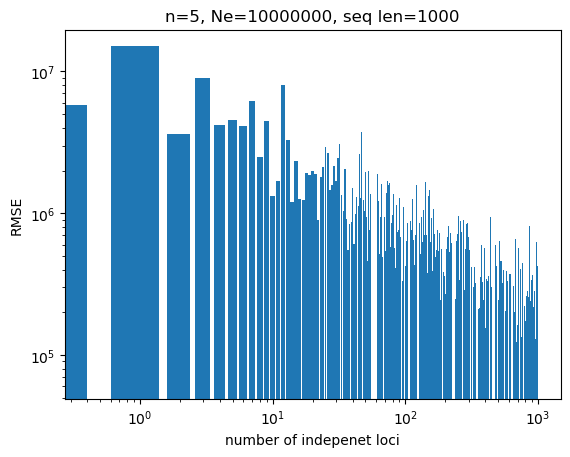

In [19]:
plt.bar(range(len(errors)), errors)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('number of indepenet loci')
plt.ylabel('RMSE')
plt.title(f'n={n}, Ne={pop_size}, seq len={loci}')
plt.show()

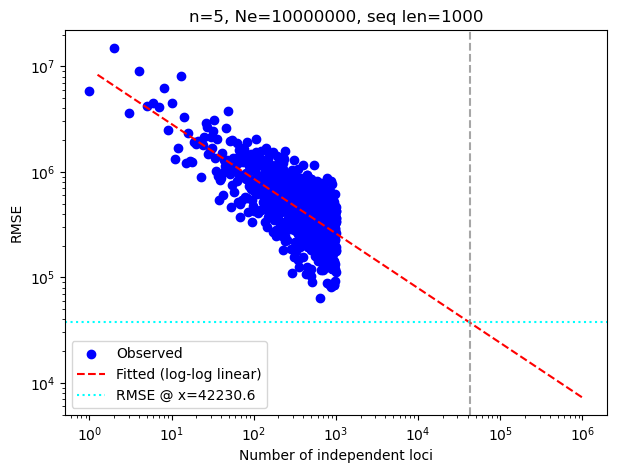

Slope: -0.519
Intercept: 6.972


In [20]:
x = np.array(range(1, len(errors)+1))  # ensure positive for log
y = np.array(errors)

# Take logs
log_x = np.log10(x).reshape(-1, 1)
log_y = np.log10(y)

# Fit linear regression in log-log space
model = LinearRegression()
model.fit(log_x, log_y)

# Generate new x values for interpolation/extrapolation
x_new = np.logspace(0.1, 6, 200)  # from 1e4 to 1e7
log_x_new = np.log10(x_new).reshape(-1, 1)

# Predict in log space, then back-transform
log_y_pred = model.predict(log_x_new)
y_pred = 10**log_y_pred

x_chrom2l = 23513712
log_x_chrom2l = np.log10(x_chrom2l)
log_y_chrom2l = model.predict([[log_x_chrom2l]])[0]
y_chrom2l = 10**log_y_chrom2l

x_max_i_loci = 42230.6
log_x_max_i_loci = np.log10(x_max_i_loci)
log_y_max_i_loci = model.predict([[log_x_max_i_loci]])[0]
y_max_i_loci = 10**log_y_max_i_loci

# Plot
plt.figure(figsize=(7,5))
plt.scatter(x, y, label='Observed', color='blue')
plt.plot(x_new, y_pred, 'r--', label='Fitted (log-log linear)')

'''plt.axhline(y_chrom2l, color='green', linestyle=':', label=f'RMSE @ x={x_chrom2l}')
plt.axvline(x_chrom2l, color='gray', linestyle='--', alpha=0.7)'''

plt.axhline(y_max_i_loci, color='cyan', linestyle=':', label=f'RMSE @ x={x_max_i_loci}')
plt.axvline(x_max_i_loci, color='gray', linestyle='--', alpha=0.7)


plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of independent loci')
plt.ylabel('RMSE')
plt.title(f'n={n}, Ne={pop_size}, seq len={loci}')
plt.legend()
plt.show()

# Optional: print regression info
print(f"Slope: {model.coef_[0]:.3f}")
print(f"Intercept: {model.intercept_:.3f}")

https://www.biorxiv.org/content/10.1101/2024.05.20.595063v1

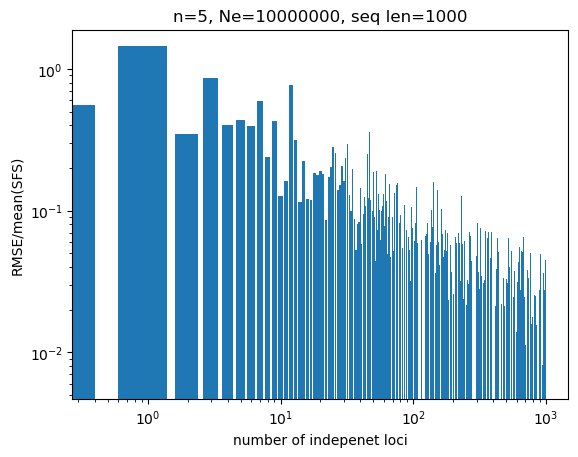

In [21]:
scaled_error = [e/np.mean(theoritical_sfs) for e in errors]
plt.bar(range(len(scaled_error)), scaled_error)
plt.yscale('log')
plt.xscale('log')

plt.xlabel('number of indepenet loci')
plt.ylabel('RMSE/mean(SFS)')
plt.title(f'n={n}, Ne={pop_size}, seq len={loci}')
plt.show()

# Varying r

In [22]:
r_range = np.logspace(-5, -1, 20)
r_range = np.concatenate([r_range, [0,1]])
r_range = np.sort(r_range)
replicates = 25

In [23]:
r_errors = []
for r in r_range:
    sfss = [0]*(n-1)
    tss = msprime.sim_ancestry(
        samples=n,
        sequence_length=loci,
        recombination_rate=r,
        ploidy=1,
        population_size=pop_size,
        model=msprime.SmcKApproxCoalescent(hull_offset=1),
        num_replicates=replicates
    )
    inner_errors = [None]*(replicates)
    sfss = [0]*(n-1)
    for i, rep in enumerate(tss):
        #sfss += (rep.allele_frequency_spectrum(polarised=True, span_normalise=True, mode='branch')[1:-1])
        sfs = rep.allele_frequency_spectrum(polarised=True, span_normalise=True, mode='branch')[1:-1]
        inner_errors[i] = error(sfs)
    #sfs = sfss/(replicates)
    error_mean = np.mean(inner_errors)

    r_errors.append(error_mean)



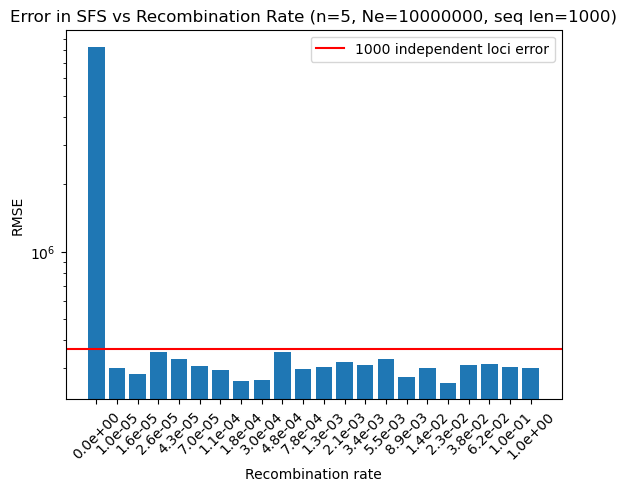

In [24]:
plt.bar(range(len(r_errors)), r_errors)
plt.yscale('log')
plt.xticks(range(len(r_errors)), [f"{r:.1e}" for r in r_range], rotation=45)
plt.axhline(y=errors[-1], color='r', linestyle='-', label=f'{loci} independent loci error')

plt.xlabel('Recombination rate')
plt.ylabel('RMSE')
plt.title(f'Error in SFS vs Recombination Rate (n={n}, Ne={pop_size}, seq len={loci})')
plt.legend()
plt.show()

In [25]:
l_range = []
l_range = list(np.linspace(20, 10000000, 20, dtype=int))
replicates = 25
recob_rate = 2.40463e-08


In [26]:
def error_len(l):
    print(l)
    sfss = [0]*(n-1)
    tss = msprime.sim_ancestry(
        samples=n,
        sequence_length=l,
        recombination_rate=recob_rate,
        ploidy=1,
        population_size=pop_size,
        model=msprime.SmcKApproxCoalescent(hull_offset=1),
        num_replicates=replicates
    )
    inner_errors = [None]*(replicates)
    sfss = [0]*(n-1)
    for i, rep in enumerate(tss):
        #sfss += (rep.allele_frequency_spectrum(polarised=True, span_normalise=True, mode='branch')[1:-1])
        sfs = rep.allele_frequency_spectrum(polarised=True, span_normalise=True, mode='branch')[1:-1]
        inner_errors[i] = error(sfs)
    #sfs = sfss/(replicates)
    error_mean = np.mean(inner_errors)
    return error_mean


def parallel_error_len(l_range, max_workers=4):
    with cf.ProcessPoolExecutor(max_workers=max_workers) as executor:
        errors = list(executor.map(error_len, l_range))
    return errors

l_errors = parallel_error_len(l_range, max_workers=2)


52633420

1052649
1578964
2105278
2631593
3157908
3684223
4210537
4736852
5263167
5789482
6315796
6842111
7368426
7894741
8421055
8947370
9473685
10000000


In [27]:
assert(len(l_range) == len(l_errors))

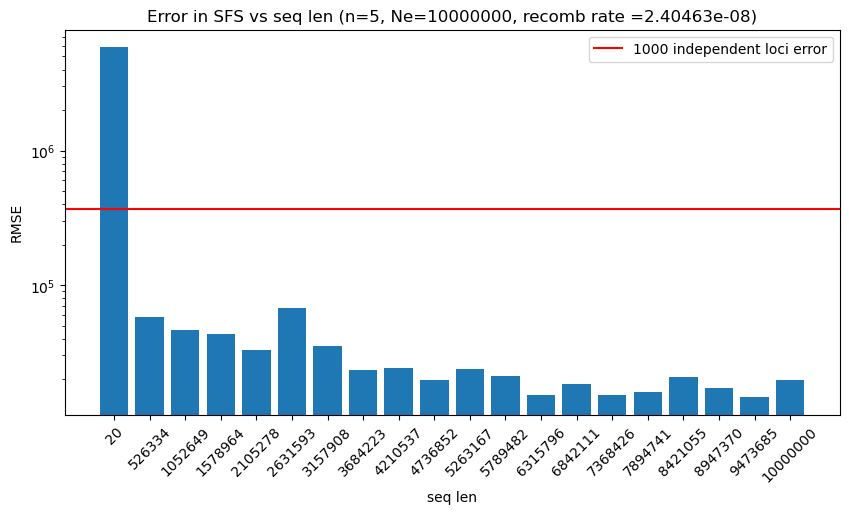

In [28]:
plt.figure(figsize=(10,5))
plt.bar(range(len(l_errors)), height=l_errors)
plt.yscale('log')
plt.xticks(range(len(l_errors)), [f"{l}" for l in l_range], rotation=45)
plt.axhline(y=errors[-1], color='r', linestyle='-', label=f'{loci} independent loci error')

plt.xlabel('seq len')
plt.ylabel('RMSE')
plt.title(f'Error in SFS vs seq len (n={n}, Ne={pop_size}, recomb rate ={recob_rate})')
plt.legend()
plt.show()